数据集形状：(150, 4)
标签类别：[0 1 2]
特征名称：['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

训练集大小：105
测试集大小：45

模型准确率：1.0000

分类报告：
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



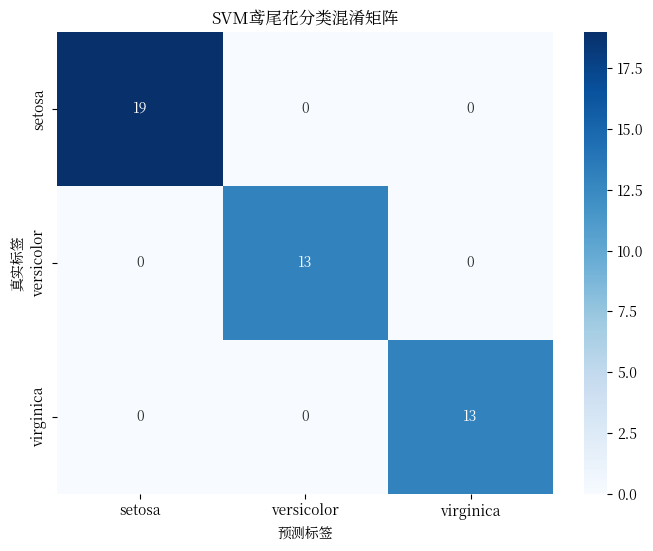

In [1]:
import numpy as np
import matplotlib.pyplot as plt   # 画图用的
plt.rcParams['font.sans-serif'] = ['Noto Serif CJK JP']        # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False          # 用来正常显示负号
from sklearn import datasets  # sklearn是机器学习库
from sklearn.model_selection import train_test_split  # 把数据分成训练集和测试集
from sklearn.preprocessing import StandardScaler          # 标准化工具
from sklearn.svm import SVC  # SVC支持向量机分类器
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  # 用来评估模型表现的
import seaborn as sns   # 基于matplotlib的统计数据可视化库

# 1. 加载数据集
iris = datasets.load_iris()
X = iris.data # 特征数据，150行x40列的表格
y = iris.target # 0、1、2是三种类型的花

print(f"数据集形状：{X.shape}")
print(f"标签类别：{np.unique(y)}")
print(f"特征名称：{iris.feature_names}")

# 2. 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42 # 70%训练集，30%测试集
)
print(f"\n训练集大小：{X_train.shape[0]}")
print(f"测试集大小：{X_test.shape[0]}")

#数据标准化
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # 用训练集拟合标准化器并转换
X_test = scaler.transform(X_test)         # 用同样的参数转换测试集

# 3. 创建并训练SVM模型
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_model.fit(X_train, y_train)

# 4. 模型预测与评估
y_pred = svm_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\n模型准确率：{accuracy:.4f}")

print("\n分类报告：")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# 绘制混淆矩阵
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.xlabel('预测标签')
plt.ylabel('真实标签')
plt.title('SVM鸢尾花分类混淆矩阵')
plt.show()